In [261]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.animation import FFMpegWriter, PillowWriter
plt.rcParams['image.origin']='lower'
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['animation.html'] = 'html5'

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
from scoob_llowfsc import iefc

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307


# Load basleine iEFC data. 

In [7]:
camsci_name = 'camlo'
camlo_name = 'camsci'
dm_lo_name = 'dm00disp02'
dm_ho_name = 'dm00disp03'

date = 20250417
data_path = scoob_llowfsc.path/'exp-data'
exp_path = data_path/f'exp-{date}'
iefc_data_path = exp_path/'iefc'



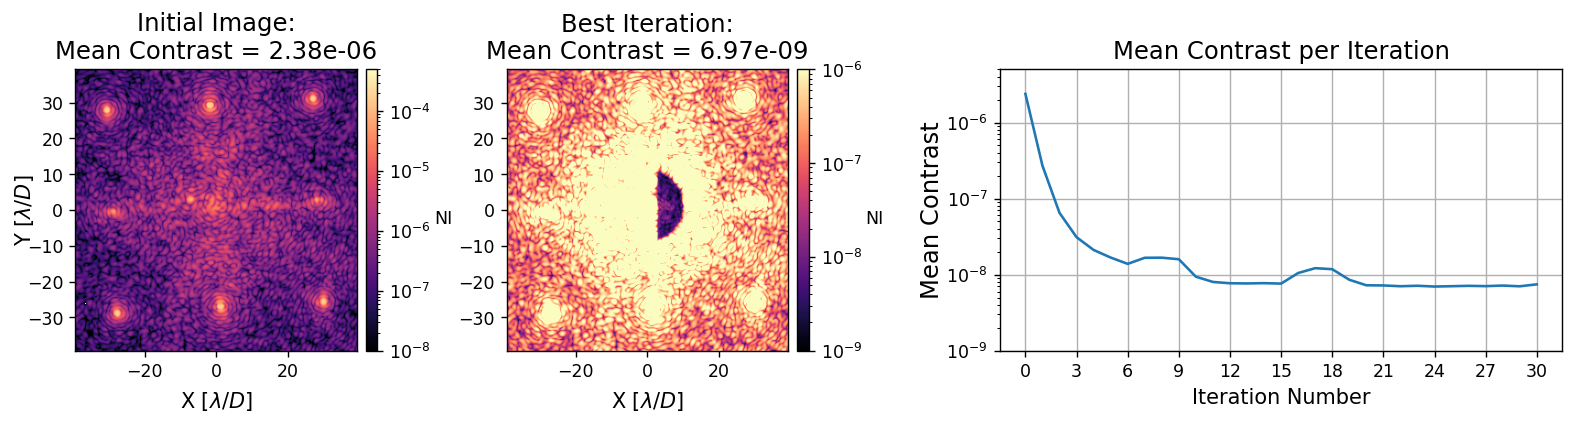

In [ ]:
iefc_data = utils.load_pickle(iefc_data_path/'iefc_run_right.pkl')
control_mask = iefc_data['control_mask']

iefc.plot_data_with_ref(
    iefc_data,
    im1vmin=1e-8, im1vmax=5e-4,
    im2vmin=1e-9, im2vmax=1e-6, 
    vmin=1e-9, vmax=5e-6,
    xticks=np.arange(0, 30.1, 3),
)

# Analyze the LLOWFSC with iEFC data. 

In [9]:
camsci_name = 'camlo'
camlo_name = 'camsci'
dm_lo_name = 'dm00disp02'
dm_ho_name = 'dm00disp03'

date = 20250418
data_path = scoob_llowfsc.path/'exp-data'
exp_path = data_path/f'exp-{date}-2'
iefc_data_path = exp_path/'iefc'
iefc_telem_path = iefc_data_path/'raw-telem'
iefc_unpacked_path = iefc_data_path/'unpacked-telem'
llowfsc_data_path = exp_path/'llowfsc'
llowfsc_telem_path = llowfsc_data_path/'raw-telem'
llowfsc_unpacked_path = llowfsc_data_path/'unpacked-telem'

camlo_ref_name = 'camlo_ref_0'
camlo_ref_offset_name = 'camlo_ref_offset'

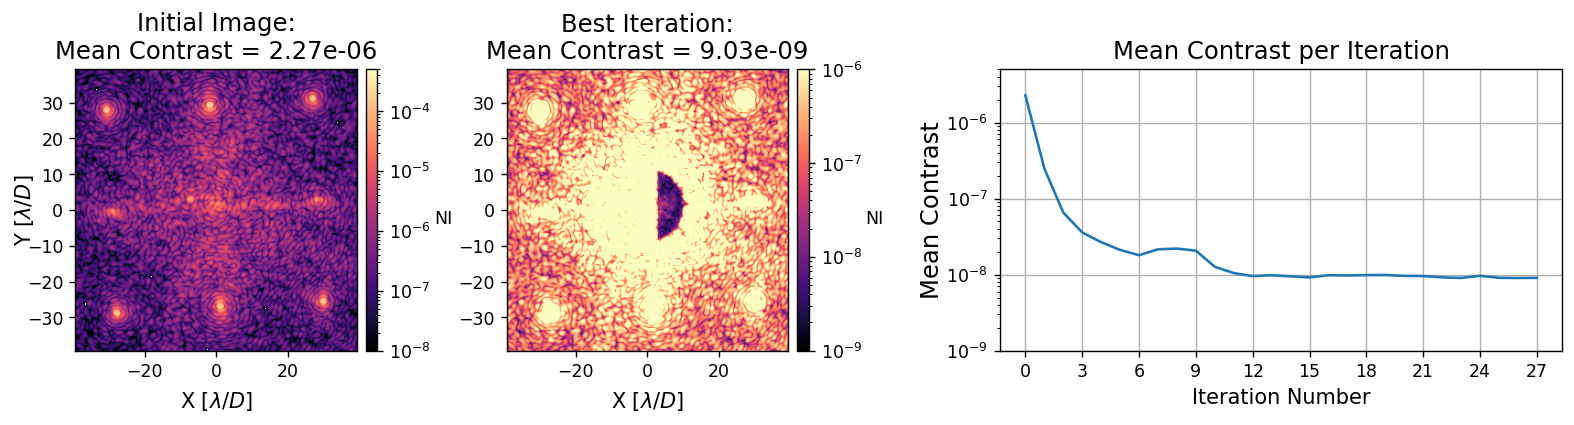

In [11]:
iefc_data = utils.load_pickle(iefc_data_path/'iefc_run_right.pkl')
control_mask = iefc_data['control_mask']

iefc.plot_data_with_ref(
    iefc_data,
    im1vmin=1e-8, im1vmax=5e-4,
    im2vmin=1e-9, im2vmax=1e-6, 
    vmin=1e-9, vmax=5e-6,
    xticks=np.arange(0, 27.1, 3),
)

In [12]:
camsci_data_fnames = telem.get_fnames(iefc_data_path/'camsci_ims_20250418*.fits')
len(camsci_data_fnames), camsci_data_fnames

(12,
 ['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_20250418143219.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_20250418144246.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_20250418145313.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_20250418150339.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_20250418151406.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_20250418152433.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_20250418153500.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_20250418154527.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/

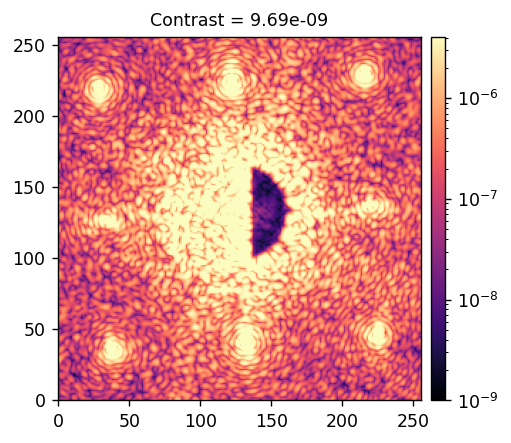

In [13]:
time_series_ims = []
start_times = []
for i in range(len(camsci_data_fnames)):
    time_series_ims.append(utils.load_fits( camsci_data_fnames[i] ))
    start_times.append( camsci_data_fnames[i][-19:-5] )
time_series_ims = xp.array(time_series_ims)
series_start = start_times[0]

mean_im = xp.mean(time_series_ims, axis=(0, 1))
mean_contrast = xp.mean(mean_im[control_mask])

utils.imshow(
    [mean_im],
    titles=[f'Contrast = {mean_contrast:.2e}'],
    norms=[LogNorm(1e-9)],
)


In [14]:
series_start_times = []
series_contrasts = []

for i in range(len(start_times)):
    t_hr = float(start_times[i][-6:-4])
    t_min = float(start_times[i][-4:-2])
    t_sec = float(start_times[i][-2:])
    series_start_times.append( 3600*t_hr + 60*t_min + t_sec ) 
    print(series_start_times[i])

    series_contrasts.append( xp.mean(time_series_ims[i, :, control_mask], axis=0) )

series_start_times = np.array( series_start_times )
series_start_times -= series_start_times[0]
print(series_start_times/60)
series_contrasts = xp.array(series_contrasts)

52339.0
52966.0
53593.0
54219.0
54846.0
55473.0
56100.0
56727.0
57354.0
57981.0
58607.0
59234.0
[  0.          10.45        20.9         31.33333333  41.78333333
  52.23333333  62.68333333  73.13333333  83.58333333  94.03333333
 104.46666667 114.91666667]


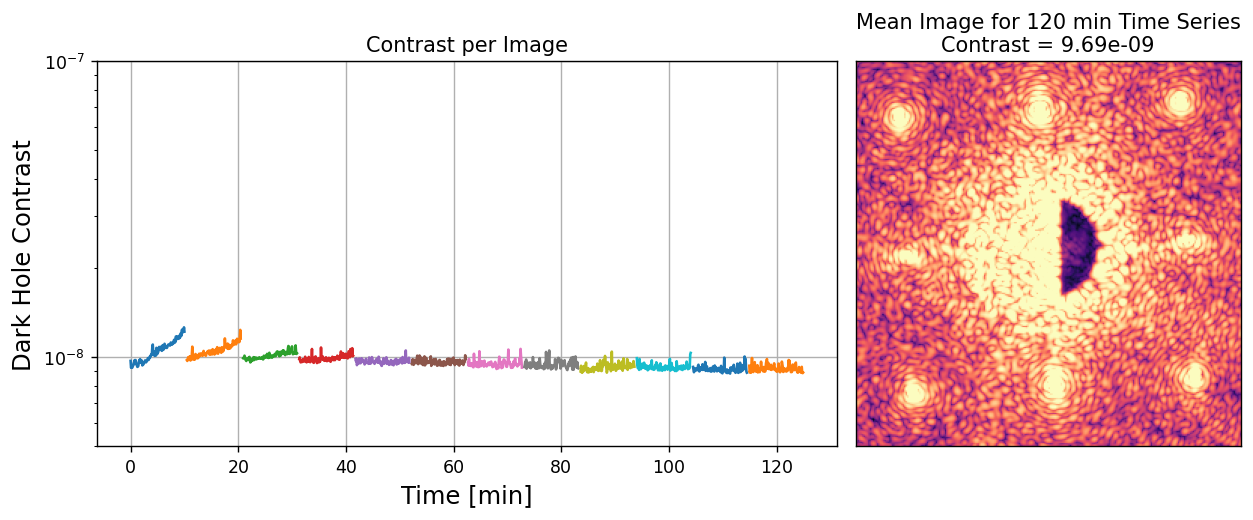

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4), dpi=125, gridspec_kw={'width_ratios': [1.75, 1], })

vmin = 5e-9
vmax = 1e-7

time_steps = np.linspace(0, 10, time_series_ims.shape[1])
for i in range(len(start_times)):
    axs[0].semilogy(time_steps + series_start_times[i]/60, ensure_np_array(series_contrasts[i]))
axs[0].set_ylim(vmin, vmax)
# axs[0].set_yticks(np.linspace(vmin, vmax, 5))
axs[0].set_ylabel('Dark Hole Contrast', fontsize=14)
axs[0].set_xlabel('Time [min]', fontsize=14)
axs[0].grid()
axs[0].set_title('Contrast per Image')

axs[1].imshow(ensure_np_array(mean_im), norm=LogNorm(1e-9), cmap='magma')
axs[1].set_title(f'Mean Image for 120 min Time Series\nContrast = {mean_contrast:.2e}')
axs[1].set_xticks([])
axs[1].set_yticks([])
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="4%", pad=0.075)
# cbar = fig.colorbar(im, cax=cax)
# cbar.ax.set_ylabel(cbar_label, rotation=0, labelpad=7)

plt.subplots_adjust(
    wspace=0.0,
)

# Aanlyze with and without reference offset data.

In [30]:
camsci_data_fnames = telem.get_fnames(iefc_data_path/'camsci_ims_without_and_with_ref_offset*.fits')
len(camsci_data_fnames), camsci_data_fnames

(1,
 ['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_without_and_with_ref_offset_20250418163830.fits'])

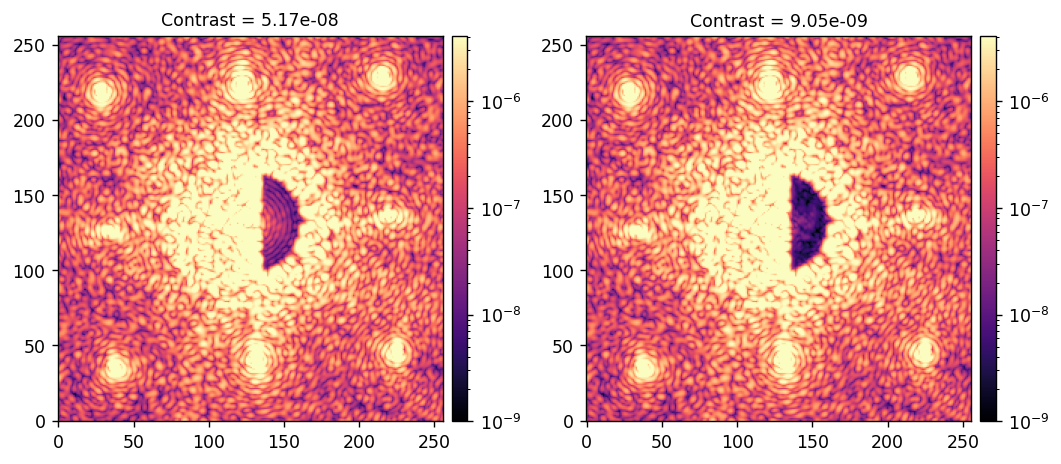

In [36]:
camsci_ims = utils.load_fits(camsci_data_fnames[0])
contrasts = xp.mean(camsci_ims[:, control_mask], axis=1)

utils.imshow(
    [camsci_ims[0], camsci_ims[-5]],
    titles=[f'Contrast = {contrasts[0]:.2e}', f'Contrast = {contrasts[-5]:.2e}'],
    norms=[LogNorm(1e-9)]*2,
)


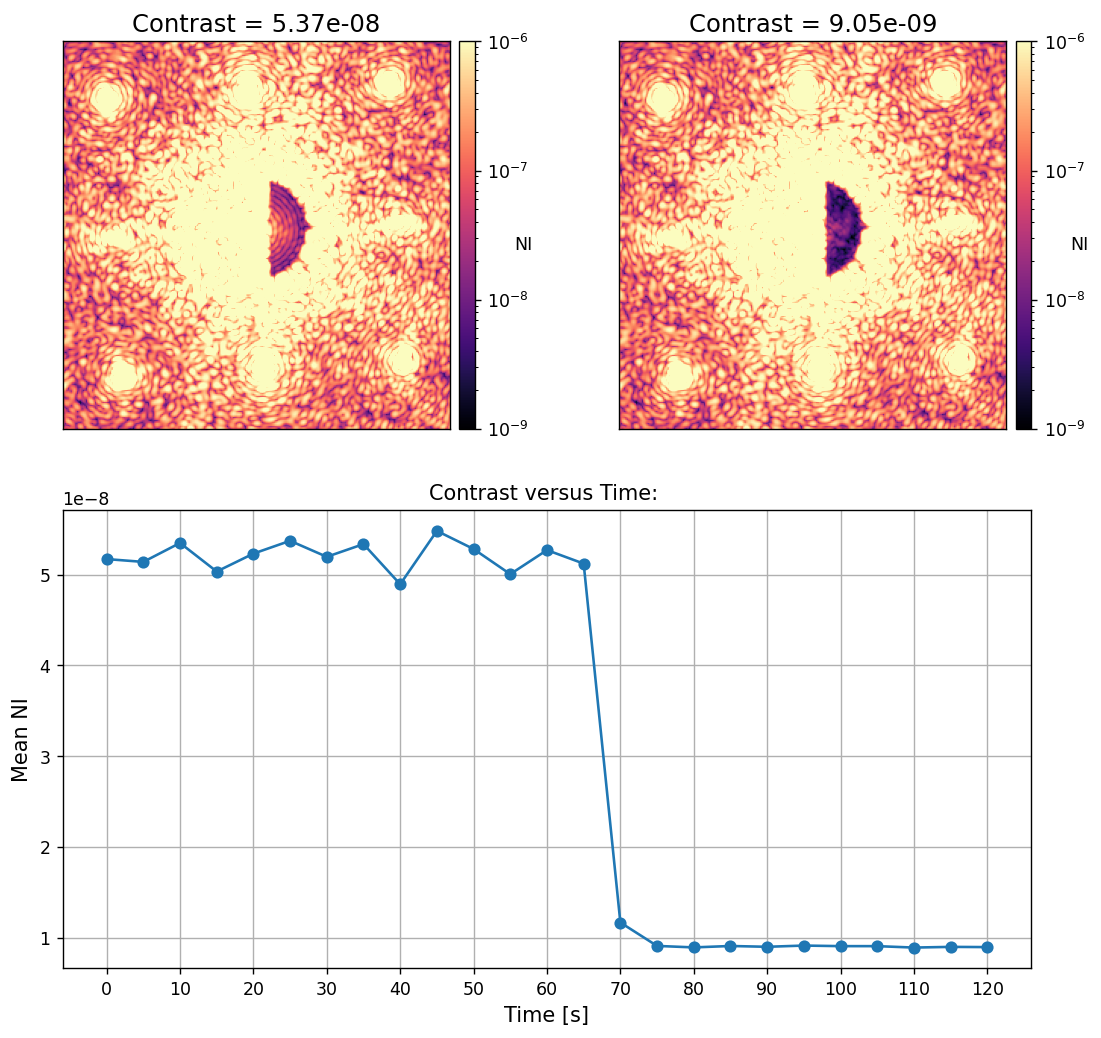

In [ ]:

figsize = (10,10)
dpi = 125

fig = plt.figure(figsize=figsize, dpi=dpi)
gs = GridSpec(2, 2, figure=fig)

ax = fig.add_subplot(gs[0,0])
im = ax.imshow(ensure_np_array(camsci_ims[5]), norm=LogNorm(1e-9, 1e-6), cmap='magma')
ax.set_title(f'Contrast = {contrasts[5]:.2e}', fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=-3)

ax = fig.add_subplot(gs[0,1])
im = ax.imshow(ensure_np_array(camsci_ims[-5]), norm=LogNorm(1e-9, 1e-6), cmap='magma')
ax.set_title(f'Contrast = {contrasts[-5]:.2e}', fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=-3)

ax = fig.add_subplot(gs[1,:])
ax.plot(time_steps, ensure_np_array(contrasts), '-o')
ax.set_title('Contrast versus Time: ')
ax.set_xlabel('Time [s]', fontsize=12)
ax.set_ylabel('Mean NI', fontsize=12)
ax.set_xticks(time_steps[::2])
ax.grid()

plt.subplots_adjust(
    wspace=0.35,
    hspace=0.1,
)

# Analyze data with varying gains.

In [186]:
camsci_data_fnames = telem.get_fnames(iefc_data_path/'camsci_ims_gains_test*.fits')
gain_vals = utils.load_pickle(iefc_data_path/'llowfsc_gains_test_vals.pkl')
len(camsci_data_fnames), camsci_data_fnames

(5,
 ['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_gains_test_1_20250418164102.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_gains_test_2_20250418164302.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_gains_test_3_20250418164502.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_gains_test_4_20250418164702.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250418-2/iefc/camsci_ims_gains_test_5_20250418164902.fits'])

(5, 256, 256) (5,)


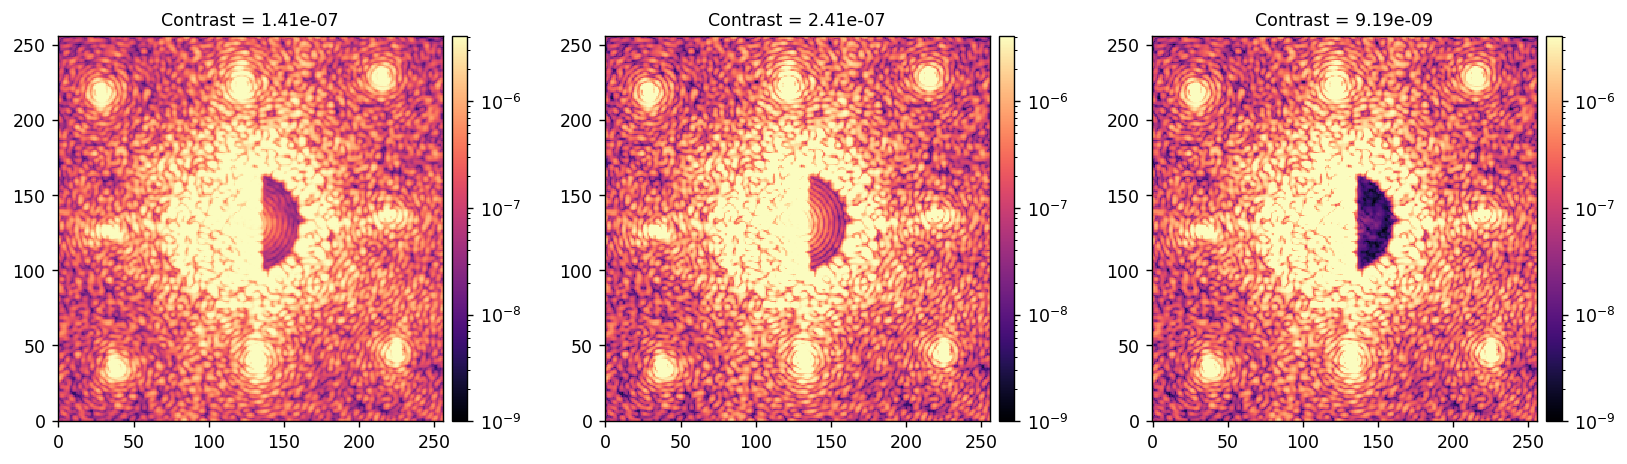

In [ ]:
time_series_ims = []
start_times = []
for i in range(len(camsci_data_fnames)):
    time_series_ims.append(utils.load_fits( camsci_data_fnames[i] ))
    start_times.append( camsci_data_fnames[i][-19:-5] )
time_series_ims = xp.array(time_series_ims)
series_start = start_times[0]

mean_ims = xp.mean(time_series_ims, axis=(1))
mean_contrasts = xp.mean(mean_ims[:, control_mask], axis=(1))
print(mean_ims.shape, mean_contrasts.shape)

utils.imshow(
    [mean_ims[0], mean_ims[1], mean_ims[-1]],
    titles=[f'Contrast = {mean_contrasts[0]:.2e}', 
            f'Contrast = {mean_contrasts[1]:.2e}',
            f'Contrast = {mean_contrasts[-1]:.2e}'],
    norms=[LogNorm(1e-9)]*5,
)

In [262]:
def create_llowfsc_gains_anim(
        camsci_ims,
        mean_nis, 
        time_steps,
        gain_vals, 
        numframes=None, 
        cmap='magma',
        norm=None,
        extent=None,
        figsize=(10,4), 
        dpi=125, 
        gridspec_kw={'width_ratios': [1, 1.75],},
        wspace=0.25,
        hspace=0.25,
        interval=0.1, # in s
    ):
    numframes = camsci_ims.shape[0] if numframes is None else numframes
    print(numframes)
    
    i = 0
    camsci_im = ensure_np_array(camsci_ims[i])
    mean_ni = ensure_np_array(mean_nis[i])
    time_val = time_steps[i]
    if time_val <= 2: current_gains = gain_vals[0][0]
    elif time_val > 2 and time_val <= 4: current_gains = gain_vals[1][0]
    elif time_val > 4 and time_val <= 6: current_gains = gain_vals[2][0]
    elif time_val > 6 and time_val <= 8: current_gains = gain_vals[3][0]
    elif time_val > 8: current_gains = gain_vals[4][0]

    fig, axs = plt.subplots(
        nrows=1, ncols=2, 
        figsize=figsize, 
        dpi=dpi, 
        gridspec_kw=gridspec_kw,
    )
    plt.subplots_adjust(
        wspace=wspace,
        hspace=hspace,
    )

    suptitle = fig.suptitle(f'Time = {time_val:.3f} min\nGains = {current_gains}', fontsize=16, y=1.15)

    ax = axs[0]
    im = ax.imshow(camsci_im, norm=norm, cmap=cmap, extent=extent)
    im_title = ax.set_title(f'CAMSCI Image\nMean NI = {mean_ni:.2e}', fontsize=14,)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.set_ylabel('Mean NI', rotation=0, labelpad=25)

    ax = axs[1]
    line, = ax.plot(ensure_np_array(time_steps[:i]), ensure_np_array(mean_nis[:i]), '-o')
    line_title = ax.set_title('Contrast over Time', fontsize=14)
    ax.set_xlim(-1, time_steps[-1]+1)
    ax.set_xlabel('Time [min]')
    ax.set_yscale('log')
    ax.set_ylim(5e-9, 1e-6)
    # ax.set_ylabel('Mean NI')
    ax.grid()

    def animate(i):
        camsci_im = ensure_np_array(camsci_ims[i])
        mean_ni = ensure_np_array(mean_nis[i])
        time_val = time_steps[i]
        if time_val <= 2: current_gains = gain_vals[0][0]
        elif time_val > 2 and time_val <= 4: current_gains = gain_vals[1][0]
        elif time_val > 4 and time_val <= 6: current_gains = gain_vals[2][0]
        elif time_val > 6 and time_val <= 8: current_gains = gain_vals[3][0]
        elif time_val > 8: current_gains = gain_vals[4][0]

        suptitle.set_text(f'Time = {time_val:.3f} min\nGains = {current_gains}')
        im_title.set_text(f'CAMSCI Image\nMean NI = {mean_ni:.2e}',)

        im.set_data(camsci_im)
        line.set_data(ensure_np_array(time_steps[:i]), ensure_np_array(mean_nis[:i]))

        # im.set_clim([0, np.max(camlo_im)])
        
    anim = matplotlib.animation.FuncAnimation(fig, animate, frames=numframes, interval=interval*1000)
    return anim

80


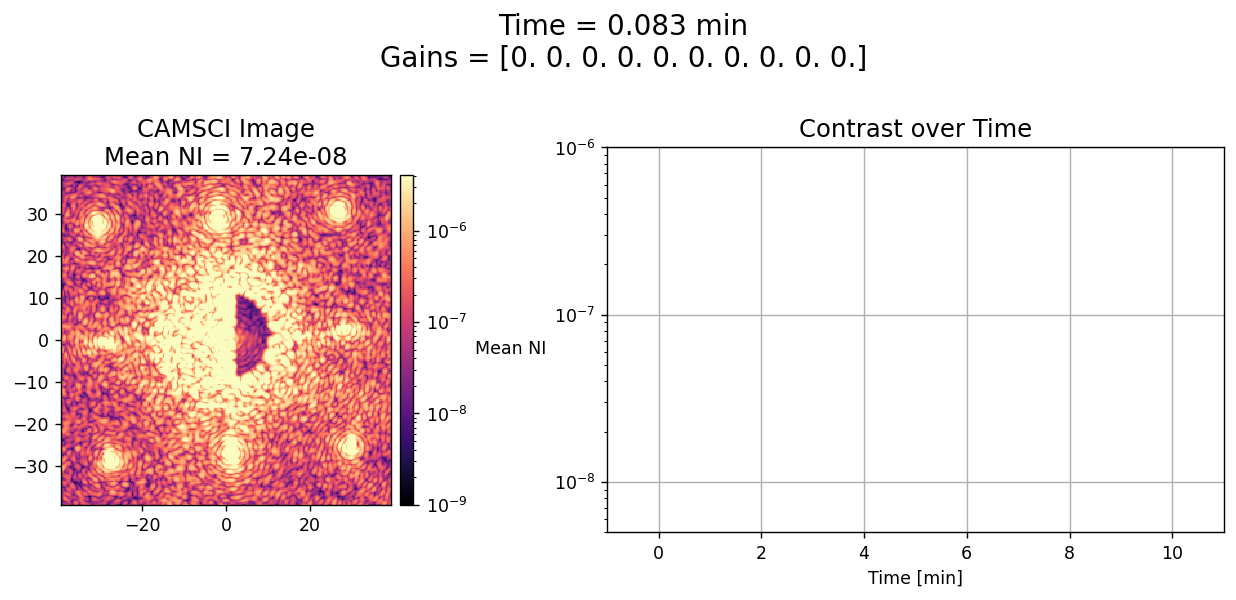

In [ ]:
camsci_ims = xp.concatenate(time_series_ims, axis=0)
mean_nis = xp.mean(camsci_ims[:, control_mask], axis=1)
time_steps = np.arange(0, 5*camsci_ims.shape[0], 5) + 5

camsci_pxscl = 0.307
ncamsci = camsci_ims.shape[1]
camsci_lim = camsci_pxscl * ncamsci/2 
camsci_extent = [-camsci_lim, camsci_lim, -camsci_lim, camsci_lim]

anim = create_llowfsc_gains_anim(
    camsci_ims,
    mean_nis,
    time_steps/60,
    gain_vals,
    # numframes=80,
    norm=LogNorm(1e-9),
    extent=camsci_extent,
    figsize=(12,4),
    wspace=0.4,
    hspace=0.5,
    interval=5/100, # in s
)

In [265]:
anim

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1500x500 -pix_fmt rgba -framerate 20.0 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpyp06xbko/temp.m4v
